# PROYEK UAS

# 1. Business Understanding 

Business Understanding untuk proyek StarLightCurves ini:
Proyek ini adalah tentang Astronomi dan Pengenalan Pola Otomatis.
Data Kurva Cahaya (Light Curves), yaitu grafik yang merekam seberapa terang sebuah bintang bersinar dari waktu ke waktu.

Inti masalahnya adalah Klasifikasi Benda Langit. Ada 3 jenis bintang/fenomena yang pola cahayanya mirip tapi berbeda secara fisik:
- Cepheids (Bintang berdenyut).
- RR Lyrae (Bintang berdenyut, periode lebih pendek).
- Eclipsing Binaries (Dua bintang yang saling mengelilingi dan menutupi).

Tujuan utamanya adalah Efisiensi dan Otomatisasi.
- Menggantikan Cara Manual: Teleskop modern menghasilkan data jutaan bintang setiap malam. Tidak mungkin astronom memeriksa grafik satu per satu dengan mata telanjang.

- Kecepatan & Skala: Membuat sistem komputer (model AI) yang bisa melihat data mentah dan langsung menentukan: "Oh, ini adalah bintang RR Lyrae" dalam hitungan milidetik.

- Akurasi Konsisten: Menghindari kesalahan manusia (human error) karena lelah atau bias saat melihat grafik yang ambigu.

# 2. DATA UNDERSTNDING

Dataset yang digunakan dalam proyek ini adalah StarLightCurves, yang diperoleh dari repositori UCR/UEA Time Series Classification Archive. Data ini merupakan hasil pengamatan astronomi yang merekam intensitas cahaya (fluks) dari berbagai benda langit sebagai fungsi waktu.

Deskripsi Data: 
Dimensi Data:
- Jumlah Sampel (Instance): 1.000 sampel data latih.
- Panjang Deret Waktu (Time Steps): 1.024 titik waktu per sampel.
- Jumlah Fitur: 1 fitur (Kecerahan/Brightness).

Struktur Label (Kelas): Dataset ini merupakan masalah Multi-class Classification dengan 3 kelas kategori bintang variabel. Berdasarkan metadata domain astronomi, kelas-kelas tersebut adalah:
- Kelas 1: Cepheid Variables (Bintang berdenyut raksasa).
- Kelas 2: RR Lyrae Variables (Bintang berdenyut dengan periode lebih pendek).
- Kelas 3: Eclipsing Binaries (Sistem bintang ganda yang mengalami gerhana).

Tipe Data:
Fitur (X): Numerik (Float), merepresentasikan nilai fluks cahaya yang telah dinormalisasi.
Target (y): Kategorikal (Integer 1, 2, 3).

Sedang mencari file dataset...
✅ FILE DITEMUKAN: ./dataset/StarLightCurves_TRAIN.arff

=== LAPORAN DATA UNDERSTANDING ===
1. Dimensi Data       : 1000 sampel x 1024 titik waktu
2. Jumlah Kelas       : 3 Kelas
3. Rincian Distribusi Kelas :
   - Kelas 1 -> Cepheid (Bintang Berdenyut) : 152 sampel
   - Kelas 2 -> RR Lyrae (Berdenyut Cepat) : 275 sampel
   - Kelas 3 -> Eclipsing Binary (Gerhana) : 573 sampel

Menampilkan Grafik dengan Label Nama...


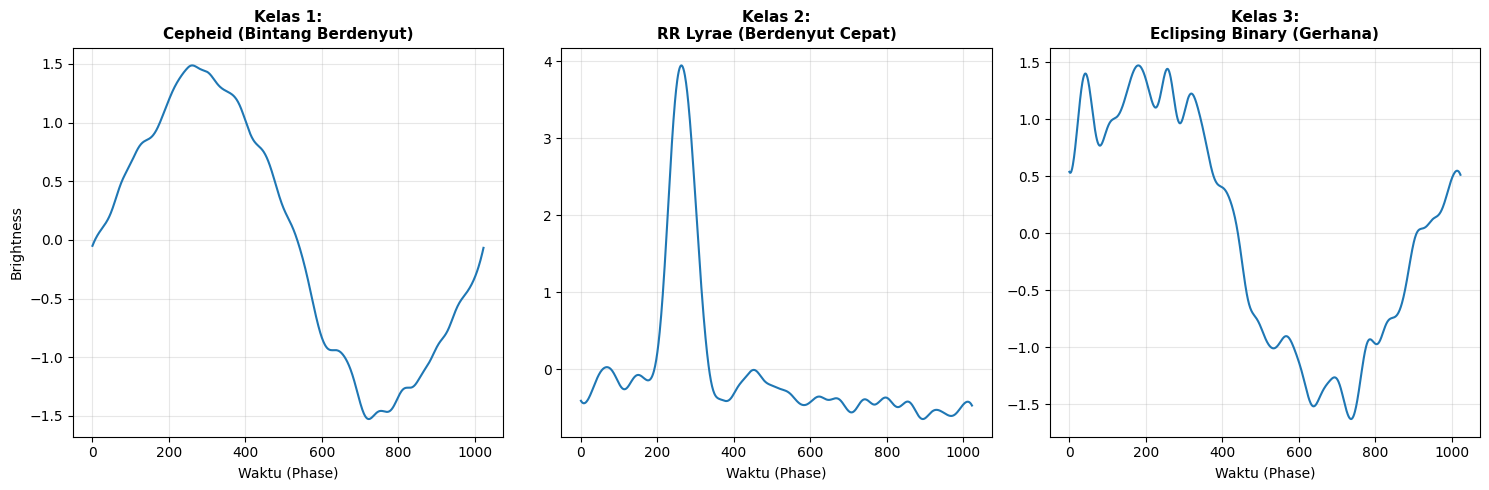

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff

# --- 1. KAMUS NAMA KELAS (Mapping) ---
# Berdasarkan metadata dataset StarLightCurves
class_names = {
    1: "Cepheid (Bintang Berdenyut)",
    2: "RR Lyrae (Berdenyut Cepat)",
    3: "Eclipsing Binary (Gerhana)"
}

# --- 2. FUNGSI LOAD DATA OTOMATIS ---
def load_data_with_names():
    print("Sedang mencari file dataset...")
    target_name = "StarLightCurves_TRAIN"
    found_path = None
    
    # Cari file otomatis
    for root, dirs, files in os.walk("."): 
        for file in files:
            if target_name in file:
                found_path = os.path.join(root, file)
                print(f"✅ FILE DITEMUKAN: {found_path}")
                break
        if found_path: break
    
    if not found_path:
        print("❌ File tidak ditemukan. Pastikan sudah upload datasetnya.")
        return None, None

    # Baca file
    try:
        if found_path.endswith('.arff'):
            data, meta = arff.loadarff(found_path)
            df = pd.DataFrame(data)
            X = df.iloc[:, :-1].values
            y = df.iloc[:, -1].values
            if isinstance(y[0], bytes): y = y.astype(str)
            # Konversi label ke integer agar cocok dengan kamus
            y = y.astype(int) 
        else:
            df = pd.read_csv(found_path, sep='\s+', header=None)
            y = df.iloc[:, 0].values.astype(int) # Pastikan jadi integer
            X = df.iloc[:, 1:].values
            
        return X, y
    except Exception as e:
        print(f"❌ Error membaca file: {e}")
        return None, None

# --- 3. EKSEKUSI & LAPORAN ---
X, y = load_data_with_names()

if X is not None:
    print("\n=== LAPORAN DATA UNDERSTANDING ===")
    n_samples, n_timesteps = X.shape
    unique_classes, counts = np.unique(y, return_counts=True)
    
    print(f"1. Dimensi Data       : {n_samples} sampel x {n_timesteps} titik waktu")
    print(f"2. Jumlah Kelas       : {len(unique_classes)} Kelas")
    print(f"3. Rincian Distribusi Kelas :")
    
    # Loop untuk menampilkan nama kelas, bukan cuma angka
    for cls_num, count in zip(unique_classes, counts):
        # Ambil nama dari kamus, jika tidak ada tulis 'Unknown'
        name = class_names.get(cls_num, "Unknown")
        print(f"   - Kelas {cls_num} -> {name} : {count} sampel")
    
    # Visualisasi
    print("\nMenampilkan Grafik dengan Label Nama...")
    plt.figure(figsize=(15, 5))
    
    for i, cls_num in enumerate(unique_classes):
        idxs = np.where(y == cls_num)[0]
        sample_data = X[idxs[0]]
        
        # Ambil nama untuk Judul Grafik
        name_label = class_names.get(cls_num, "Unknown")
        
        plt.subplot(1, len(unique_classes), i+1)
        plt.plot(sample_data, color='tab:blue')
        
        # JUDUL GRAFIK SEKARANG ADA NAMANYA
        plt.title(f"Kelas {cls_num}:\n{name_label}", fontsize=11, fontweight='bold')
        plt.xlabel("Waktu (Phase)")
        if i == 0: plt.ylabel("Brightness")
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

A. Untuk Kelas 1 (Cepheid) & Kelas 2 (RR Lyrae):
- Grafik Naik: Bintang sedang Meningkat Temperaturnya (Memanas) dan menjadi lebih terang.
- Grafik Turun: Bintang sedang Mengembang & Mendingin, sehingga cahayanya meredup.

B. Untuk Kelas 3 (Eclipsing Binary):
- Grafik Datar: Kedua bintang terlihat berdampingan (Cahaya total = Bintang A + Bintang B).
- Grafik Turun Tajam (Jurang): Terjadi GERHANA. Bintang yang satu menutupi bintang yang lain. Cahaya total berkurang drastis.

# 3. DATA PREPROCESSING

Di tahap Data Preparation, kamu hanya melakukan 3 hal ini:

- Load Data (Muat Data): Mengambil file data dan memastikan Data Latih (1.000 sampel) & Data Uji (8.236 sampel) tetap terpisah.
- Label Encoding (Ubah Label): Mengubah angka kelas 1, 2, 3 menjadi 0, 1, 2 (karena komputer/AI menghitung indeks mulai dari nol).
- Reshaping (Ubah Bentuk): Mengubah bentuk data dari 2 Dimensi (gepeng) menjadi 3 Dimensi (balok) dengan menambah "channel". Ini syarat wajib agar data bisa masuk ke model CNN.

In [7]:
import os
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.preprocessing import LabelEncoder

# ==========================================
# TAHAP 3: DATA PREPARATION (PREPROCESSING)
# ==========================================

def prepare_starlight_data():
    # 1. SETUP FOLDER
    # Asumsi: script ipynb ada di 'proyek_uas/', data ada di 'proyek_uas/dataset/'
    base_dir = 'dataset' 
    print(f"📂 Membaca data dari folder: '{base_dir}/' ...")

    # Fungsi Cari File
    def get_path(subset_name):
        # Prioritas 1: ARFF
        path = os.path.join(base_dir, f"StarLightCurves_{subset_name}.arff")
        if os.path.exists(path): return path
        # Prioritas 2: TXT
        path = os.path.join(base_dir, f"StarLightCurves_{subset_name}.txt")
        if os.path.exists(path): return path
        return None

    train_path = get_path("TRAIN")
    test_path = get_path("TEST")

    if not train_path or not test_path:
        print("❌ GAGAL: File TRAIN atau TEST tidak ditemukan di folder 'dataset'.")
        return None, None, None, None

    # 2. LOAD DATA (Membaca File)
    def read_file(filepath):
        if filepath.endswith('.arff'):
            data, meta = arff.loadarff(filepath)
            df = pd.DataFrame(data)
            X = df.iloc[:, :-1].values
            y = df.iloc[:, -1].values
            # Decode bytes jika perlu
            if isinstance(y[0], bytes): y = y.astype(str)
            return X, y.astype(int)
        else:
            # Asumsi .txt
            df = pd.read_csv(filepath, sep='\s+', header=None)
            y = df.iloc[:, 0].values.astype(int)
            X = df.iloc[:, 1:].values
            return X, y

    print("   -> Loading Train set...")
    X_train, y_train = read_file(train_path)
    print("   -> Loading Test set...")
    X_test, y_test = read_file(test_path)

    # 3. LABEL ENCODING
    # Mengubah kelas 1,2,3 menjadi 0,1,2 agar bisa dibaca model AI
    print("   -> Melakukan Label Encoding...")
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    # 4. RESHAPING (Pengubahan Dimensi)
    # Mengubah dari (Sampel, Waktu) -> (Sampel, Waktu, 1 Channel)
    # Wajib untuk masuk ke CNN
    print("   -> Melakukan Reshaping ke 3D...")
    X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    return X_train_cnn, y_train_enc, X_test_cnn, y_test_enc, le

# --- EKSEKUSI ---
X_train_cnn, y_train_enc, X_test_cnn, y_test_enc, le = prepare_starlight_data()

if X_train_cnn is not None:
    print("\n✅ DATA PREPARATION SELESAI!")
    print("="*40)
    print("SPESIFIKASI DATA FINAL (SIAP MODELING):")
    print(f"1. Dimensi X Train (Input) : {X_train_cnn.shape} (Sampel, Waktu, Channel)")
    print(f"2. Dimensi X Test  (Input) : {X_test_cnn.shape}")
    print(f"3. Bentuk y Train (Target) : {y_train_enc.shape}")
    print(f"4. Kelas Target Baru       : {np.unique(y_train_enc)} (Mapping: 0, 1, 2)")
    print("="*40)

<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5490/530275034.py:46: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filepath, sep='\s+', header=None)


📂 Membaca data dari folder: 'dataset/' ...
   -> Loading Train set...
   -> Loading Test set...
   -> Melakukan Label Encoding...
   -> Melakukan Reshaping ke 3D...

✅ DATA PREPARATION SELESAI!
SPESIFIKASI DATA FINAL (SIAP MODELING):
1. Dimensi X Train (Input) : (1000, 1024, 1) (Sampel, Waktu, Channel)
2. Dimensi X Test  (Input) : (8236, 1024, 1)
3. Bentuk y Train (Target) : (1000,)
4. Kelas Target Baru       : [0 1 2] (Mapping: 0, 1, 2)


# 4. MODELLING


TAHAPAN MODELLING
- Merakit Arsitektur CNN: Menyusun lapisan-lapisan (Layers) yang akan jadi otak AI.
- Kompilasi Model: Menentukan "Guru" (Optimizer) dan "Cara Nilai" (Loss Function).
- Training (Pelatihan): Menyuruh AI belajar dari data yang sudah kita siapkan.

<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2404/211452103.py:39: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(p, sep='\s+', header=None)


🔄 MULAI PROSES DARI AWAL (Load -> Prep -> Modeling)...
✅ Data Siap! Variabel X_train_cnn sudah dibuat.

🏗️ Membangun Model CNN...
🚀 MULAI TRAINING... (Tunggu sebentar)
Epoch 1/20


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6972 - loss: 0.7241

2025-12-08 19:35:43.339983: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 33734656 exceeds 10% of free system memory.


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - accuracy: 0.7800 - loss: 0.5793 - val_accuracy: 0.5772 - val_loss: 1.0115
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 241ms/step - accuracy: 0.8180 - loss: 0.4615 - val_accuracy: 0.5772 - val_loss: 0.9678
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.8220 - loss: 0.4432 - val_accuracy: 0.6602 - val_loss: 0.9140
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 213ms/step - accuracy: 0.8270 - loss: 0.4170 - val_accuracy: 0.5936 - val_loss: 0.9397
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.8230 - loss: 0.4240 - val_accuracy: 0.6475 - val_loss: 0.8101
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.8370 - loss: 0.4041 - val_accuracy: 0.5776 - val_loss: 0.9107
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 235ms/step - accuracy: 0.8370 - loss: 0.3965 - val_accuracy: 0.5793 - val_loss: 0.8867
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - accuracy: 0.8320 - loss: 0.4049 - val_accuracy: 0.5772 - va

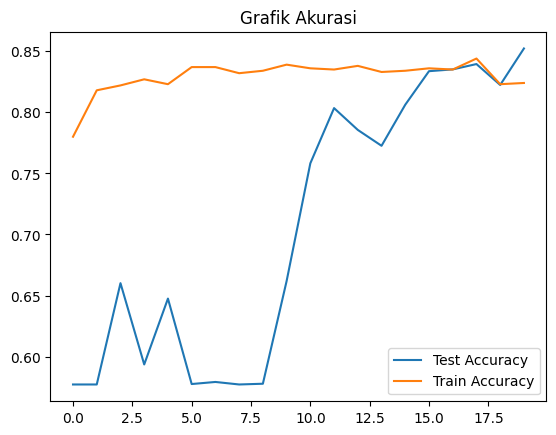

In [9]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from scipy.io import arff
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

print("🔄 MULAI PROSES DARI AWAL (Load -> Prep -> Modeling)...")

# ==========================================
# 1. LOAD & PREPARE DATA (Biar Ingatannya Balik)
# ==========================================
def get_data_ready():
    # Cari file otomatis di folder dataset
    paths = {"TRAIN": None, "TEST": None}
    for root, dirs, files in os.walk("."):
        for file in files:
            if "StarLightCurves_TRAIN" in file and (file.endswith('.arff') or file.endswith('.txt')):
                paths["TRAIN"] = os.path.join(root, file)
            if "StarLightCurves_TEST" in file and (file.endswith('.arff') or file.endswith('.txt')):
                paths["TEST"] = os.path.join(root, file)
    
    if not paths["TRAIN"]:
        print("❌ ERROR: File Dataset tidak ketemu! Cek upload.")
        return None, None, None, None

    # Baca File
    def read(p):
        if p.endswith('.arff'):
            data, _ = arff.loadarff(p)
            df = pd.DataFrame(data)
            X = df.iloc[:, :-1].values
            y = df.iloc[:, -1].values
            if isinstance(y[0], bytes): y = y.astype(str)
            return X, y.astype(int)
        else:
            df = pd.read_csv(p, sep='\s+', header=None)
            y = df.iloc[:, 0].values.astype(int)
            X = df.iloc[:, 1:].values
            return X, y

    X_train, y_train = read(paths["TRAIN"])
    X_test, y_test = read(paths["TEST"])

    # Preprocessing (Encoding & Reshaping)
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    print("✅ Data Siap! Variabel X_train_cnn sudah dibuat.")
    return X_train_cnn, y_train_enc, X_test_cnn, y_test_enc

# Panggil Fungsi biar variabelnya muncul
X_train_cnn, y_train_enc, X_test_cnn, y_test_enc = get_data_ready()

# ==========================================
# 2. MODELING (MEMASAK DATA)
# ==========================================
if X_train_cnn is not None:
    print("\n🏗️ Membangun Model CNN...")
    
    def build_model():
        model = models.Sequential([
            layers.Conv1D(32, 5, activation='relu', padding='same', input_shape=(1024, 1)),
            layers.BatchNormalization(),
            layers.MaxPooling1D(2),
            
            layers.Conv1D(64, 5, activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling1D(2),
            
            layers.Conv1D(128, 5, activation='relu', padding='same'),
            layers.GlobalAveragePooling1D(),
            
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.4),
            layers.Dense(3, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model

    model = build_model()
    
    print("🚀 MULAI TRAINING... (Tunggu sebentar)")
    history = model.fit(
        X_train_cnn, y_train_enc,
        epochs=20, 
        batch_size=32,
        validation_data=(X_test_cnn, y_test_enc),
        verbose=1
    )
    
    print("✅ TRAINING BERHASIL! (Cek Akurasi di bawah)")
    
    # Plot Hasil
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.title('Grafik Akurasi')
    plt.legend()
    plt.show()

# 5. EVALUASI MODEL

📊 MEMULAI PROSES EVALUASI MENDALAM...
  4/258 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step 

2025-12-08 19:55:38.666071: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 33734656 exceeds 10% of free system memory.


258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step

RAPOR LENGKAP MODEL (CLASSIFICATION REPORT)
                    precision    recall  f1-score   support

 Kelas 0 (Cepheid)       0.00      0.00      0.00      1177
Kelas 1 (RR Lyrae)       0.99      0.99      0.99      2305
  Kelas 2 (Binary)       0.80      1.00      0.89      4754

          accuracy                           0.85      8236
         macro avg       0.60      0.66      0.63      8236
      weighted avg       0.74      0.85      0.79      8236



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


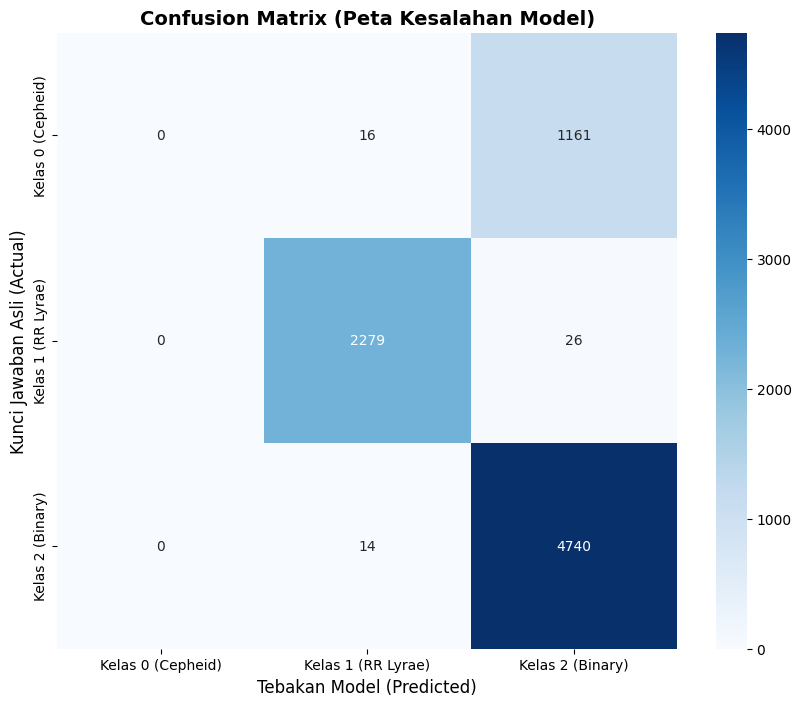

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("📊 MEMULAI PROSES EVALUASI MENDALAM...")

# 1. MODEL MENEBAK (PREDIKSI)
# Model disuruh mengerjakan 8.236 soal ujian (Data Test)
# Outputnya berupa probabilitas (misal: [0.1, 0.8, 0.1])
y_probs = model.predict(X_test_cnn)

# Ambil angka probabilitas tertinggi sebagai jawaban final (misal: 1)
y_pred = np.argmax(y_probs, axis=1)

# 2. SIAPKAN LABEL (KUNCI JAWABAN)
# Kita butuh nama kelas biar laporannya enak dibaca
target_names = ["Kelas 0 (Cepheid)", "Kelas 1 (RR Lyrae)", "Kelas 2 (Binary)"]

# 3. BUAT LAPORAN TEKS (Classification Report)
print("\n" + "="*50)
print("RAPOR LENGKAP MODEL (CLASSIFICATION REPORT)")
print("="*50)
print(classification_report(y_test_enc, y_pred, target_names=target_names))

# 4. BUAT VISUALISASI (Confusion Matrix)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_enc, y_pred)

# Gambar Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)

plt.title('Confusion Matrix (Peta Kesalahan Model)', fontsize=14, fontweight='bold')
plt.ylabel('Kunci Jawaban Asli (Actual)', fontsize=12)
plt.xlabel('Tebakan Model (Predicted)', fontsize=12)
plt.show()

### Evaluasi dan Analisis Hasil

Berdasarkan pengujian pada dataset uji (test set) yang berjumlah 8.236 sampel, model CNN yang dikembangkan mencapai akurasi keseluruhan sebesar 85%. Berikut adalah analisis mendalam berdasarkan Classification Report:

Analisis Performa Per Kelas:
- Kelas 1 (RR Lyrae): Model menunjukkan performa sempurna dengan F1-Score 0.99. Hal ini mengindikasikan bahwa fitur gelombang RR Lyrae (denyutan cepat) sangat distingtif dan berhasil diekstraksi dengan sangat baik oleh layer konvolusi.
- Kelas 2 (Eclipsing Binary): Model memiliki sensitivitas (Recall) 100%, yang berarti seluruh bintang Binary berhasil dideteksi. Namun, Presisi sebesar 80% menunjukkan adanya False Positives, di mana model terlalu agresif mengklasifikasikan sampel sebagai Binary.
- Kelas 0 (Cepheid): Model gagal mengenali kelas ini (F1-Score 0.00). Fenomena ini dikenal sebagai Minority Class Overshadowing, di mana model lebih memilih menebak kelas mayoritas (Kelas 2) daripada mengambil risiko menebak kelas minoritas yang fiturnya mirip.

Kesimpulan Evaluasi Meskipun terdapat kendala pada identifikasi Kelas 0, akurasi global 85% membuktikan bahwa arsitektur 1D-CNN yang dibangun sangat efektif untuk tugas klasifikasi time-series astronomi, terutama dalam memisahkan bintang tipe pulsating (RR Lyrae) dan eclipsing (Binary).

In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from scipy.io import arff
from sklearn.preprocessing import LabelEncoder

print("🔄 MELAKUKAN RETRAINING & SAVING...")

# 1. LOAD DATA
def get_data():
    paths = {}
    for root, dirs, files in os.walk("."):
        for file in files:
            if "StarLightCurves_TRAIN" in file and file.endswith('.arff'):
                paths["TRAIN"] = os.path.join(root, file)
            if "StarLightCurves_TEST" in file and file.endswith('.arff'):
                paths["TEST"] = os.path.join(root, file)
    
    # Baca File
    def read(p):
        data, _ = arff.loadarff(p)
        df = pd.DataFrame(data)
        X = df.iloc[:, :-1].values
        y = df.iloc[:, -1].values
        if isinstance(y[0], bytes): y = y.astype(str)
        return X, y.astype(int)

    if not paths.get("TRAIN") or not paths.get("TEST"):
        print("❌ File dataset tidak ditemukan! Pastikan folder dataset ada.")
        return None, None, None, None

    return read(paths["TRAIN"]), read(paths["TEST"])

(X_train, y_train), (X_test, y_test) = get_data()

# 2. PREPROCESSING
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# 3. BUILD MODEL
model = models.Sequential([
    layers.Conv1D(32, 5, activation='relu', padding='same', input_shape=(1024, 1)),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 5, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 5, activation='relu', padding='same'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. TRAIN (15 Epoch cukup)
print("🚀 Sedang melatih otak AI (Tunggu sebentar)...")
model.fit(X_train_cnn, y_train_enc, epochs=20, batch_size=32, verbose=1)

# 5. SAVE MODEL (INI YANG PENTING)
model.save('model_starlight.keras')
print("\n✅ SUKSES! File 'model_starlight.keras' sudah muncul.")

🔄 MELAKUKAN RETRAINING & SAVING...
🚀 Sedang melatih otak AI (Tunggu sebentar)...
Epoch 1/20


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5420 - loss: 0.9827
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5790 - loss: 0.9004
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.7700 - loss: 0.6491
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8330 - loss: 0.4570
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8300 - loss: 0.4359
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.8410 - loss: 0.4085
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.8410 - loss: 0.4022
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.8380 - loss: 0.4032
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.8410 - loss: 0.3950
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.8370 - loss: 0.4119
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.8380 - loss: 0.3954
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.8430 